# Calibration & abstention

Reproduces the **calibration / abstention** panels of the DeepCell Types paper.
These diagnostics characterize the **frozen-CLS max-softmax** confidence and the
**per-(tissue, modality) IQR-fence cell-type abstention** policy used at the
paper's headline operating point (**k = 0.2**):

- **calibration_reliability** — reliability diagram (12-bin, ±5 pp envelope) + ECE.
- **calibration_confidence_by_correctness** — confidence histograms split by
  hierarchical correctness, with the median IQR fence overlaid.
- **iqr_coverage_macro_f1_pareto** — coverage vs macro-F1 Pareto for the
  per-group IQR fence vs a global max-softmax threshold τ; paper operating point starred.
- **iqr_per_class_abstention_rate** — per-class abstention rate at k = 0.2 (lineage-colored).
- **iqr_per_group_fence** — the actual per-(tissue, modality) fence values (modality-colored).
- **calibration_reliability_by_lineage** — reliability stratified by true-label lineage.
- **iqr_pareto_macro_f1 / iqr_pareto_weighted_f1** — val-picked-operating-point Pareto
  curves from the precomputed val→test IQR sweep JSON.
- **fov_abstention_exemplar** — a held-out test FOV showing where abstention triggers
  (correct / mispredicted / abstained cells).

The IQR fence is computed via the torch-free vendored `dct_figures.scoring`
helpers; per-group buckets come from the v10 zarr archive attrs. Figures are
styled to the **Science Advances 2026** figure spec via `dct_figures.style`.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from dct_figures import paths, style, colors, scoring
style.apply_style()

## Shared config

The workspace script pulls `ct2idx` and `lineage_mapping` from a
`TissueNetConfig` (which imports `torch`). Here we use the torch-free vendored
`scoring.CT2IDX` (51-class canonical order), the analysis lineage taxonomy from
`data/lineage_mapping.yaml`, and the per-(tissue, modality) group metadata read
from the v10 zarr archive attrs.

We load the Frozen-CLS test predictions once and derive: per-cell max-softmax
confidence, argmax prediction, hierarchical-correctness flag
(`scoring.CELL_TYPE_HIERARCHY`), and the per-cell `tissue|modality` group key
used by the IQR fence.

In [2]:
import yaml
from dct_figures.scoring import CELL_TYPE_HIERARCHY, adjust_conf_mat_hierarchy

ct2idx = scoring.CT2IDX
idx2ct = {v: k for k, v in ct2idx.items()}
n_classes = len(ct2idx)

with open(paths.DATA_ROOT / 'lineage_mapping.yaml') as f:
    lineage_map = yaml.safe_load(f)

OPERATING_K = 0.2  # paper headline operating point
FROZEN_CLS_CSV = paths.OUTPUT / 'final_frozen_cls_test_prediction.csv'

# (tissue, modality) per dataset, from the v10 zarr archive attrs. The
# workspace script upper-cases modality for the panel-E colors; mirror that.
_meta = scoring.load_dataset_metadata(paths.EXPANDED_TISSUENET_ZARR).copy()
_meta['modality'] = _meta['modality'].fillna('unknown').astype(str).str.upper()
_meta['tissue'] = _meta['tissue'].fillna('unknown').astype(str)

_df_raw = pd.read_csv(paths.need(FROZEN_CLS_CSV))
class_cols = [c for c in _df_raw.columns if c in ct2idx]
_probs = _df_raw[class_cols].to_numpy(dtype=np.float32)
_pred_i = _probs.argmax(axis=1)
max_prob = _probs[np.arange(_probs.shape[0]), _pred_i]
pred_labels = np.array(class_cols)[_pred_i]
true_labels = _df_raw['cell_type_actual'].to_numpy(dtype=str)

# (tissue, modality) group key per cell.
_m = _df_raw[['dataset_name']].merge(_meta, on='dataset_name', how='left')
_m['tissue'] = _m['tissue'].fillna('unknown')
_m['modality'] = _m['modality'].fillna('unknown')
groups = (_m['tissue'].astype(str) + '|' + _m['modality'].astype(str)).to_numpy()
modalities = _m['modality'].to_numpy()


def _hier_correct(true_l, pred_l):
    correct = (true_l == pred_l)
    for parent, children in CELL_TYPE_HIERARCHY.items():
        forgive = (true_l == parent) & np.isin(pred_l, list(children))
        correct = correct | forgive
    return correct

correct = _hier_correct(true_labels, pred_labels)
print(f'{len(max_prob):,} cells | {len(np.unique(groups))} (tissue, modality) groups '
      f'| baseline hier-correct = {correct.mean()*100:.2f}%')

486,705 cells | 11 (tissue, modality) groups | baseline hier-correct = 89.77%


### IQR fence + scoring primitives

The per-group Tukey lower fence, the kept-mask, the IQR k-sweep, and the
global-threshold τ-sweep — all lifted verbatim from
`plot_calibration_and_abstention.py` (torch-free; the scoring is the same
hierarchy-adjusted macro/weighted F1 used elsewhere).

In [3]:
def _score(true_l, pred_l):
    n = len(ct2idx)
    cm = np.zeros((n, n), dtype=np.int64)
    for t, p in zip(true_l, pred_l):
        if t in ct2idx and p in ct2idx:
            cm[ct2idx[t], ct2idx[p]] += 1
    cm = adjust_conf_mat_hierarchy(cm, CELL_TYPE_HIERARCHY, ct2idx)
    support = cm.sum(axis=1)
    has = support > 0
    tp = np.diag(cm).astype(float)
    pred_sum = cm.sum(axis=0).astype(float)
    recall = np.zeros_like(tp); precision = np.zeros_like(tp)
    np.divide(tp, support, out=recall, where=support > 0)
    np.divide(tp, pred_sum, out=precision, where=pred_sum > 0)
    f1 = np.zeros_like(tp); denom = recall + precision
    np.divide(2 * recall * precision, denom, out=f1, where=denom > 0)
    return {'macro_acc': float(recall[has].mean() * 100.0),
            'macro_f1': float(f1[has].mean() * 100.0)}


def _group_fences(mp, grps, k):
    out = {}
    for g in np.unique(grps):
        v = mp[grps == g]
        if len(v) < 4:
            out[g] = -np.inf
            continue
        q1, q3 = np.quantile(v, [0.25, 0.75])
        out[g] = float(q1 - k * (q3 - q1))
    return out


def _iqr_keep(mp, grps, k):
    fences = _group_fences(mp, grps, k)
    fence_per_cell = np.array([fences[g] for g in grps])
    return mp >= fence_per_cell, fences


def _iqr_sweep(mp, grps, true_l, pred_l, ks):
    rows = [{'k': None, 'coverage': 1.0, **_score(true_l, pred_l)}]
    for k in ks:
        keep, _ = _iqr_keep(mp, grps, k)
        rows.append({'k': float(k), 'coverage': float(keep.mean()),
                     **_score(true_l[keep], pred_l[keep])})
    return rows


def _global_threshold_sweep(mp, true_l, pred_l, taus):
    rows = []
    for tau in taus:
        keep = mp >= tau
        if keep.sum() == 0:
            continue
        rows.append({'tau': float(tau), 'coverage': float(keep.mean()),
                     **_score(true_l[keep], pred_l[keep])})
    return rows


KS = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
TAUS = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

iqr_rows = _iqr_sweep(max_prob, groups, true_labels, pred_labels, KS)
tau_rows = _global_threshold_sweep(max_prob, true_labels, pred_labels, TAUS)
keep_op, fences_op = _iqr_keep(max_prob, groups, OPERATING_K)
median_fence = float(np.median([v for v in fences_op.values() if np.isfinite(v)]))
print(f'k={OPERATING_K}: coverage={keep_op.mean()*100:.2f}%, median fence={median_fence:.3f}')

k=0.2: coverage=82.06%, median fence=0.578


## calibration_reliability

Reliability diagram for the Frozen-CLS softmax (test split, 12-bin, ±5 pp
envelope). The model is rank-ordered but over-confident; the 15-bin ECE is
printed in the corner.

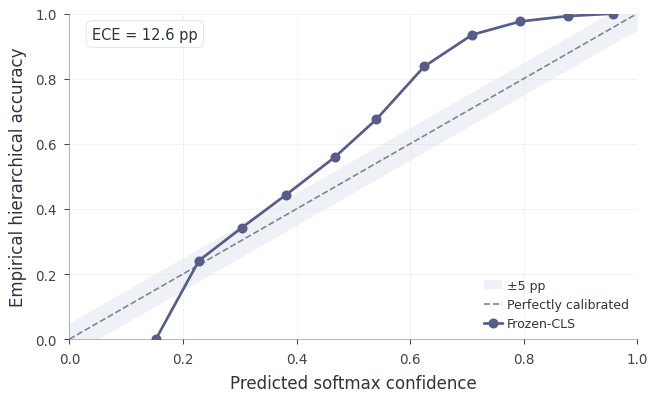

In [4]:
from dct_figures.style import PAL, COL_1_5, style_ax

def _panel_A(ax, max_prob, correct):
    n_bins = 12
    bin_edges = np.linspace(0, 1, n_bins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.clip(np.digitize(max_prob, bin_edges) - 1, 0, n_bins - 1)
    conf = centers.copy()
    acc = np.full(n_bins, np.nan)
    counts = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        m = idx == i
        if m.any():
            conf[i] = max_prob[m].mean(); acc[i] = correct[m].mean()
            counts[i] = int(m.sum())
    valid = counts > 0
    xs = np.linspace(0, 1, 200)
    ax.fill_between(xs, np.clip(xs - 0.05, 0, 1), np.clip(xs + 0.05, 0, 1),
                    color=PAL['light_gray'], alpha=0.4, linewidth=0, zorder=1,
                    label='±5 pp')
    ax.plot([0, 1], [0, 1], color=PAL['gray'], linestyle='--', linewidth=0.8,
            label='Perfectly calibrated', zorder=2)
    ax.plot(conf[valid], acc[valid], marker='o', color=PAL['theme'],
            linewidth=1.3, markersize=3.8, label='Frozen-CLS', zorder=4)
    edges15 = np.linspace(0, 1, 16)
    idx15 = np.clip(np.digitize(max_prob, edges15) - 1, 0, 14)
    n = len(max_prob); ece = 0.0
    for i in range(15):
        m = idx15 == i
        if m.any():
            ece += (m.sum() / n) * abs(correct[m].mean() - max_prob[m].mean())
    ax.text(0.04, 0.96, f'ECE = {ece * 100:.1f} pp', transform=ax.transAxes,
            ha='left', va='top', fontsize=7.0,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=PAL['light_gray'], alpha=0.9))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted softmax confidence')
    ax.set_ylabel('Empirical hierarchical accuracy')
    ax.legend(loc='lower right', fontsize=6.0, framealpha=0.92,
              handletextpad=0.4, borderaxespad=0.3)
    style_ax(ax, grid_axis='both')

fig, ax = plt.subplots(figsize=(COL_1_5, 2.8))
_panel_A(ax, max_prob, correct)
fig.tight_layout()
plt.show()

## calibration_confidence_by_correctness

Max-softmax confidence histograms split by hierarchical correctness, with the
**median per-(tissue, modality) IQR fence** at the operating k overlaid (dashed
line) — the abstention precision the policy is trading on.

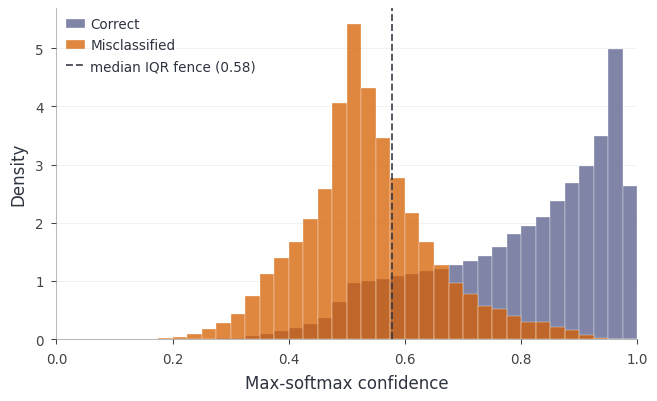

In [5]:
from dct_figures.style import PAL, COL_1_5, style_ax

def _panel_B(ax, max_prob, correct, median_fence):
    bins = np.linspace(0, 1, 41)
    ax.hist(max_prob[correct], bins=bins, color=PAL['theme'], alpha=0.75,
            density=True, edgecolor='white', linewidth=0.2, label='Correct')
    ax.hist(max_prob[~correct], bins=bins, color=PAL['red'], alpha=0.75,
            density=True, edgecolor='white', linewidth=0.2, label='Misclassified')
    ax.axvline(median_fence, color=PAL['dark'], linestyle='--', linewidth=0.9,
               alpha=0.85, zorder=5,
               label=f'median IQR fence ({median_fence:.2f})')
    ax.set_xlabel('Max-softmax confidence'); ax.set_ylabel('Density')
    ax.set_xlim(0, 1)
    ax.legend(loc='upper left', fontsize=6.5, framealpha=0.92,
              handletextpad=0.4, borderaxespad=0.3)
    style_ax(ax, grid_axis='y')

fig, ax = plt.subplots(figsize=(COL_1_5, 2.8))
_panel_B(ax, max_prob, correct, median_fence)
fig.tight_layout()
plt.show()

## iqr_coverage_macro_f1_pareto

Coverage–macro-F1 Pareto: the per-group IQR fence (sweeping k) vs a single
**global max-softmax threshold τ**. The gap between the curves is the
justification for the per-group fence; the paper operating point (k = 0.2) is
starred.

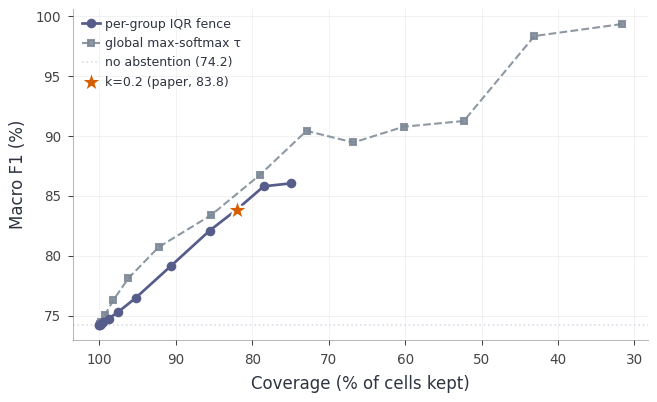

In [6]:
from dct_figures.style import PAL, COL_1_5, style_ax

def _panel_C(ax, iqr_rows, tau_rows, op_k):
    iqr = [r for r in iqr_rows if r['k'] is not None]
    iqr.sort(key=lambda r: r['coverage'])
    cov_iqr = np.array([r['coverage'] * 100 for r in iqr])
    f1_iqr = np.array([r['macro_f1'] for r in iqr])
    ax.plot(cov_iqr, f1_iqr, marker='o', color=PAL['theme'], linewidth=1.3,
            markersize=3.6, label='per-group IQR fence', zorder=4)
    tau_sorted = sorted(tau_rows, key=lambda r: r['coverage'])
    cov_tau = np.array([r['coverage'] * 100 for r in tau_sorted])
    f1_tau = np.array([r['macro_f1'] for r in tau_sorted])
    ax.plot(cov_tau, f1_tau, marker='s', color=PAL['gray'], linewidth=1.0,
            markersize=3.0, linestyle='--', label='global max-softmax τ',
            zorder=3, alpha=0.85)
    base = next(r for r in iqr_rows if r['k'] is None)
    ax.axhline(base['macro_f1'], color=PAL['light_gray'], linestyle=':',
               linewidth=0.8, zorder=1,
               label=f"no abstention ({base['macro_f1']:.1f})")
    op = next(r for r in iqr if abs(r['k'] - op_k) < 1e-9)
    ax.scatter([op['coverage'] * 100], [op['macro_f1']], s=130, color=PAL['red'],
               edgecolor='white', linewidth=1.1, marker='*', zorder=6,
               label=f"k={op_k} (paper, {op['macro_f1']:.1f})")
    ax.invert_xaxis()
    ax.set_xlabel('Coverage (% of cells kept)'); ax.set_ylabel('Macro F1 (%)')
    ax.legend(loc='upper left', fontsize=6.0, framealpha=0.92,
              handletextpad=0.4, borderaxespad=0.3)
    style_ax(ax, grid_axis='both')

fig, ax = plt.subplots(figsize=(COL_1_5, 2.8))
_panel_C(ax, iqr_rows, tau_rows, OPERATING_K)
fig.tight_layout()
plt.show()

## iqr_per_class_abstention_rate

Per-class abstention rate at the paper operating k (lineage-colored bars; classes
with < 50 cells dropped as a noise floor). Answers "are we boosting macro F1 by
dumping the rare classes?"

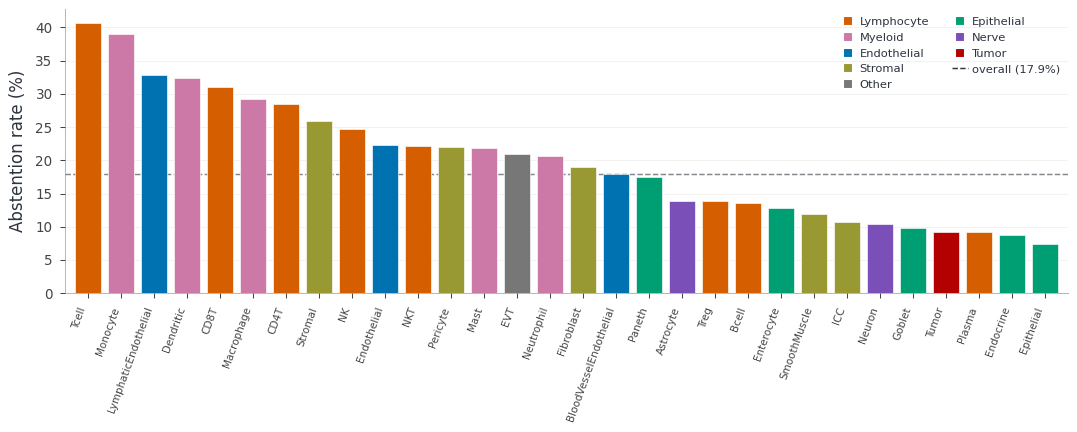

In [7]:
from dct_figures.style import PAL, COL_2, BAR_WIDTH, FS_TINY, style_ax
from dct_figures.colors import LINEAGE_ANCHORS

# Per-class abstention rate at operating k (classes with support >= 50).
abst_rate = {}
for c in np.unique(true_labels):
    if c not in ct2idx:
        continue
    m = (true_labels == c)
    n_c = int(m.sum())
    if n_c < 50:
        continue
    abst_rate[c] = (float((~keep_op & m).sum() / n_c), n_c)

def _panel_D(ax, abst_rate_by_class, lineage_map, op_k):
    items = sorted(abst_rate_by_class.items(), key=lambda kv: -kv[1][0])
    classes = [c for c, _ in items]
    rates = np.array([r for _, (r, _) in items])
    supports = np.array([n for _, (_, n) in items])
    lineages = [lineage_map.get(c, 'Other') for c in classes]
    bcolors = [LINEAGE_ANCHORS.get(lin, '#888888') for lin in lineages]
    x = np.arange(len(classes))
    ax.bar(x, rates * 100, color=bcolors, edgecolor='white', linewidth=0.3,
           width=BAR_WIDTH, zorder=3)
    overall = float(np.average(rates, weights=supports)) if supports.sum() else 0.0
    ax.axhline(overall * 100, color=PAL['dark'], linestyle='--', linewidth=0.7,
               alpha=0.6, zorder=2, label=f'overall ({overall * 100:.1f}%)')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=70, ha='right', fontsize=FS_TINY)
    ax.set_xlim(-0.7, len(classes) - 0.3)
    ax.set_ylabel('Abstention rate (%)')
    seen = list(dict.fromkeys(lineages))
    handles = [plt.Line2D([0], [0], marker='s', color='white',
                          markerfacecolor=LINEAGE_ANCHORS.get(lin, '#888888'),
                          markeredgecolor='white', markersize=5, label=lin)
               for lin in seen]
    handles.append(plt.Line2D([0], [0], color=PAL['dark'], linestyle='--',
                              linewidth=0.7, label=f'overall ({overall * 100:.1f}%)'))
    ax.legend(handles=handles, loc='upper right', fontsize=5.5, framealpha=0.92,
              handletextpad=0.3, borderaxespad=0.3,
              ncols=2 if len(seen) > 4 else 1)
    style_ax(ax, grid_axis='y')

fig, ax = plt.subplots(figsize=(COL_2, 3.0))
_panel_D(ax, abst_rate, lineage_map, OPERATING_K)
fig.tight_layout()
plt.show()

## iqr_per_group_fence

Per-(tissue, modality) IQR fence on max-softmax at the operating k, sorted and
modality-colored, with the median guide. Demonstrates the policy is genuinely
heterogeneous across groups — not a global threshold in disguise.

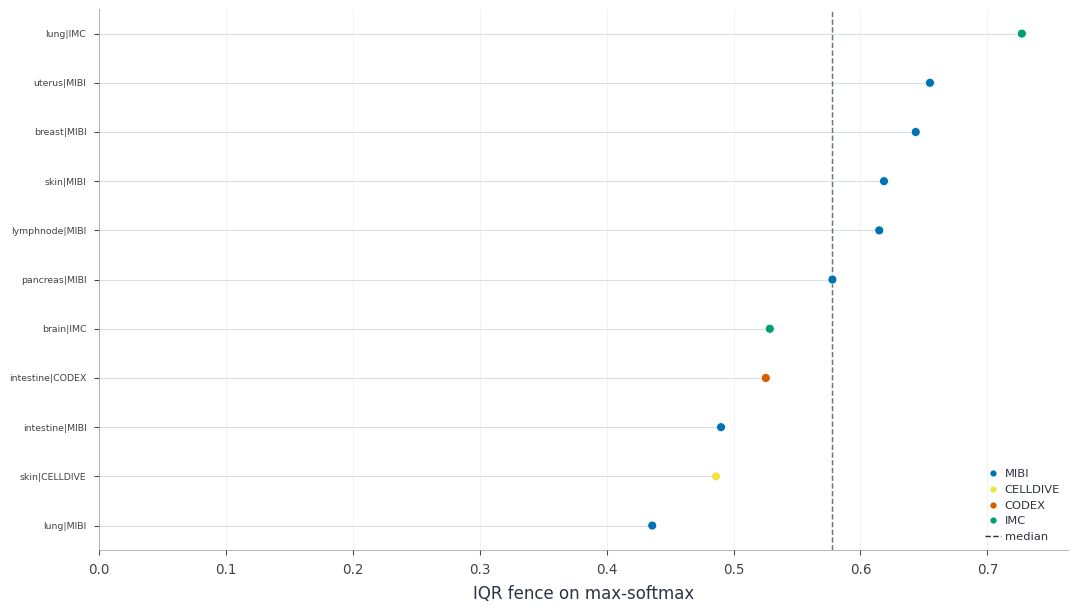

In [8]:
from dct_figures.style import PAL, COL_2, style_ax

MODALITY_COLORS = {
    'MIBI': '#0072B2', 'CODEX': '#D55E00', 'IMC': '#009E73', 'IBEX': '#CC79A7',
    'CYCIF': '#56B4E9', 'MACSIMA': '#E69F00', 'CELLDIVE': '#F0E442',
    'unknown': '#888888',
}

# group -> modality (modality constant within a tissue|modality group).
group_modality = {}
for g, m in zip(groups, modalities):
    group_modality.setdefault(g, m)

def _panel_E(ax, fences_at_op, group_modalities, median_fence):
    items = [(g, fences_at_op[g], group_modalities[g])
             for g in fences_at_op if np.isfinite(fences_at_op[g])]
    items.sort(key=lambda t: t[1])
    grps = [t[0] for t in items]
    vals = np.array([t[1] for t in items])
    mods = [t[2] for t in items]
    bcolors = [MODALITY_COLORS.get(m, MODALITY_COLORS['unknown']) for m in mods]
    y = np.arange(len(grps))
    x_lo = min(0.0, float(vals.min()))
    ax.hlines(y, x_lo, vals, color=PAL['light_gray'], linewidth=0.5, zorder=2)
    ax.scatter(vals, y, color=bcolors, s=18, edgecolor='white', linewidth=0.3,
               zorder=4)
    ax.axvline(median_fence, color=PAL['dark'], linestyle='--', linewidth=0.7,
               alpha=0.7, zorder=3, label=f'median ({median_fence:.2f})')
    ax.set_yticks(y); ax.set_yticklabels(grps, fontsize=4.5)
    ax.set_xlim(x_lo, max(0.05, float(vals.max()) * 1.05))
    ax.set_xlabel('IQR fence on max-softmax')
    seen = list(dict.fromkeys(mods))
    handles = [plt.Line2D([0], [0], marker='o', color='white',
                          markerfacecolor=MODALITY_COLORS.get(m, MODALITY_COLORS['unknown']),
                          markeredgecolor='white', markersize=4, label=m)
               for m in seen]
    handles.append(plt.Line2D([0], [0], color=PAL['dark'], linestyle='--',
                              linewidth=0.7, label='median'))
    ax.legend(handles=handles, loc='lower right', fontsize=5.5, framealpha=0.92,
              handletextpad=0.3, borderaxespad=0.3, ncols=1)
    style_ax(ax, grid_axis='x')

fig, ax = plt.subplots(figsize=(COL_2, 4.2))
_panel_E(ax, fences_op, group_modality, median_fence)
fig.tight_layout()
plt.show()

## calibration_reliability_by_lineage

Reliability diagram stratified by **true-cell-type lineage** (Frozen-CLS,
hierarchical eval, 12 equal-width confidence bins; bins with < 100 cells in the
lineage dropped). One subplot per lineage; titles show n and per-lineage ECE.

  Epithelial   ECE=15.17pp
  Lymphocyte   ECE=14.64pp
  Endothelial  ECE=13.86pp
  Nerve        ECE=13.04pp
  Myeloid      ECE=12.62pp
  Stromal      ECE=11.47pp
  Tumor        ECE=9.78pp
  Other        ECE=9.13pp


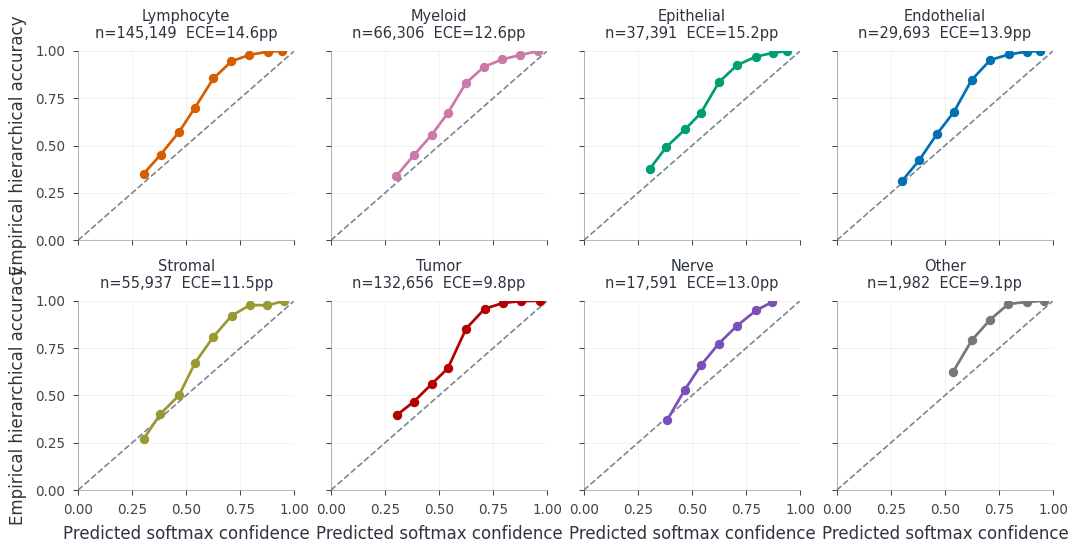

In [9]:
from dct_figures.style import LINEAGE_ORDER, PAL, COL_2, FS_BODY, style_ax
from dct_figures.colors import LINEAGE_ANCHORS

def _panel_by_lineage(axes, max_prob, correct, true_labels, lineage_map,
                      min_cells_per_bin=100):
    n_bins = 12
    bin_edges = np.linspace(0, 1, n_bins + 1)
    lineages_arr = np.array([lineage_map.get(c, 'Other') for c in true_labels])
    axes_flat = np.asarray(axes).reshape(-1)
    arr = np.asarray(axes)
    n_rows = arr.shape[0] if arr.ndim == 2 else 1
    n_cols = arr.shape[1] if arr.ndim == 2 else len(axes_flat)
    ece_by_lineage = {}
    for slot, lin in enumerate(LINEAGE_ORDER):
        if slot >= len(axes_flat):
            break
        ax = axes_flat[slot]
        row, col = slot // n_cols, slot % n_cols
        sel = lineages_arr == lin
        n_lin = int(sel.sum())
        ax.plot([0, 1], [0, 1], color=PAL['gray'], linestyle='--',
                linewidth=0.8, zorder=2)
        if n_lin > 0:
            mp_lin = max_prob[sel]; c_lin = correct[sel]
            idx = np.clip(np.digitize(mp_lin, bin_edges) - 1, 0, n_bins - 1)
            conf = np.full(n_bins, np.nan); acc = np.full(n_bins, np.nan)
            counts = np.zeros(n_bins, dtype=int)
            for i in range(n_bins):
                m = idx == i
                if m.any():
                    conf[i] = mp_lin[m].mean(); acc[i] = c_lin[m].mean()
                    counts[i] = int(m.sum())
            valid = counts >= min_cells_per_bin
            edges15 = np.linspace(0, 1, 16)
            idx15 = np.clip(np.digitize(mp_lin, edges15) - 1, 0, 14)
            ece = 0.0
            for i in range(15):
                m = idx15 == i
                if m.sum() >= min_cells_per_bin:
                    ece += (m.sum() / n_lin) * abs(c_lin[m].mean() - mp_lin[m].mean())
            ece_by_lineage[lin] = float(ece)
            color = LINEAGE_ANCHORS.get(lin, '#888888')
            ax.plot(conf[valid], acc[valid], marker='o', color=color,
                    linewidth=1.3, markersize=3.5, zorder=4)
            title = f'{lin}\nn={n_lin:,}  ECE={ece * 100:.1f}pp'
        else:
            title = f'{lin}\nn=0'
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_title(title, fontsize=FS_BODY)
        if row == n_rows - 1:
            ax.set_xlabel('Predicted softmax confidence')
        if col == 0:
            ax.set_ylabel('Empirical hierarchical accuracy')
        style_ax(ax, grid_axis='both')
    for slot in range(len(LINEAGE_ORDER), len(axes_flat)):
        axes_flat[slot].axis('off')
    return ece_by_lineage

fig, axes = plt.subplots(2, 4, figsize=(COL_2, 3.8), sharex=True, sharey=True)
ece_by_lineage = _panel_by_lineage(axes, max_prob, correct, true_labels, lineage_map)
fig.tight_layout(w_pad=0.4, h_pad=0.6)
for lin, ece in sorted(ece_by_lineage.items(), key=lambda kv: -kv[1]):
    print(f'  {lin:12s} ECE={ece*100:.2f}pp')
plt.show()

## iqr_pareto_macro_f1 / iqr_pareto_weighted_f1

Coverage–F1 Pareto curves for the IQR-fence CT abstention, read from the
precomputed **val→test** sweep JSON (`data/output/iqr_sweep_frozen_cls.json`,
produced by `analysis.iqr_sweep_val_to_test`). The val-picked operating point
(k = 0.2) is starred on the test curve.

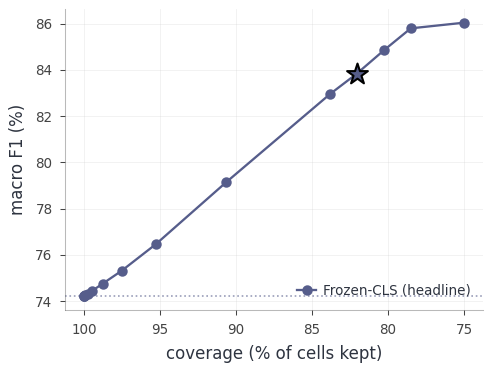

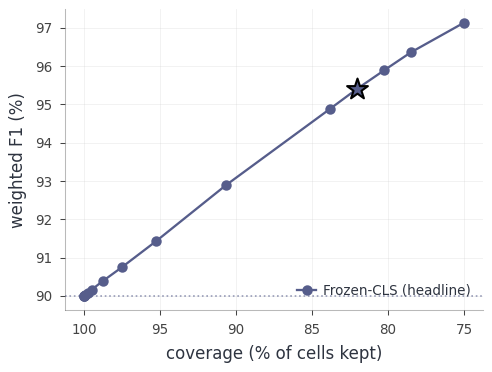

In [10]:
import json
from dct_figures.style import PAL, THEME, COL_1, FS_TICK, style_ax

with open(paths.need(paths.OUTPUT / 'iqr_sweep_frozen_cls.json')) as f:
    sweep = json.load(f)

METRICS = [('macro_f1', 'macro F1 (%)'), ('weighted_f1', 'weighted F1 (%)')]

for metric_key, ylabel in METRICS:
    fig, ax = plt.subplots(figsize=(COL_1, 2.6))
    test_rows = sorted([r for r in sweep['test_sweep'] if r['k'] is not None],
                       key=lambda r: r['k'])
    cov = [r['coverage'] * 100 for r in test_rows]
    vals = [r[metric_key] for r in test_rows]
    ax.plot(cov, vals, '-o', color=THEME, label='Frozen-CLS (headline)',
            markersize=4)
    base = next(r for r in sweep['test_sweep'] if r['k'] is None)
    ax.axhline(base[metric_key], color=THEME, linestyle=':', linewidth=0.8,
               alpha=0.6)
    op = next(r for r in sweep['test_sweep'] if r['k'] == OPERATING_K)
    ax.scatter([op['coverage'] * 100], [op[metric_key]], s=110, color=THEME,
               edgecolor='black', linewidth=1.0, marker='*', zorder=5)
    ax.set_xlabel('coverage (% of cells kept)'); ax.set_ylabel(ylabel)
    ax.invert_xaxis()
    ax.legend(loc='lower right', fontsize=FS_TICK)
    style_ax(ax, grid_axis='both')
    fig.tight_layout()
    plt.show()

## fov_abstention_exemplar

Three-state exemplar (`karimi_brain_imc_glioma_Glioma_084C1`, IMC / brain):
correctly-classified cells in lineage color, mispredictions outlined and
cross-hatched, abstained cells (max-softmax below the per-(tissue, modality)
Tukey lower fence at k = 0.2) shown in gray. Reads the raw mask crop from the v10
zarr archive; abstention is computed inline via the vendored IQR fence. (Slower
panel — loads image data.)

FOV=karimi_brain_imc_glioma_Glioma_084C1: 4609 cells | correct=3389 mispred=250 abstain=970 (rate=0.210)


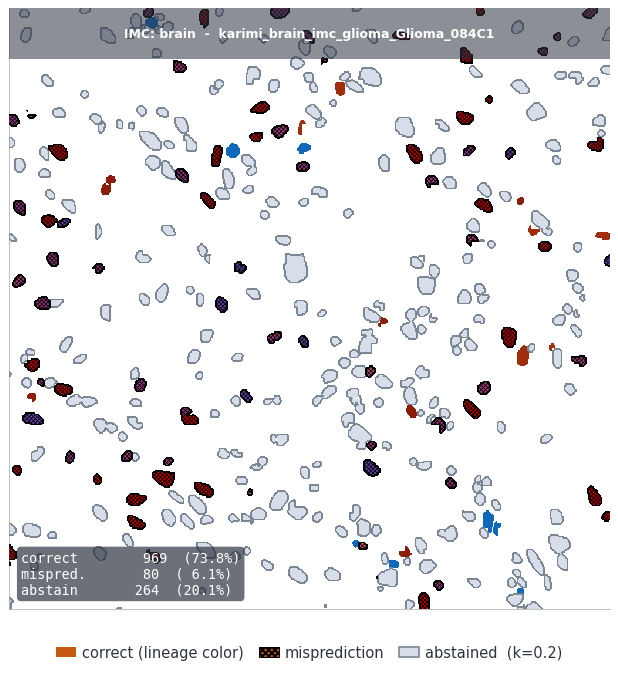

In [11]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import zarr
from scipy.ndimage import binary_dilation
from dct_figures.style import PAL, COL_1_5, FS_SMALL, FS_TICK, FS_BODY
from dct_figures.colors import celltype_color_mapping

FOV = 'karimi_brain_imc_glioma_Glioma_084C1'
K = OPERATING_K
CROP_SIDE = 1024

_T_CHILD = {'CD4T', 'CD8T', 'Treg', 'NKT'}
_S_CHILD = {'Fibroblast', 'Pericyte'}

def _hier_match(pred, gt):
    if pred == gt:
        return True
    if gt == 'Tcell' and pred in _T_CHILD:
        return True
    if pred == 'Tcell' and gt in _T_CHILD:
        return True
    if gt == 'Stromal' and pred in _S_CHILD:
        return True
    if pred == 'Stromal' and gt in _S_CHILD:
        return True
    return False

# --- best_square_crop (vendored from analysis/fov_crop.py) ---
def best_square_crop(density, side, stride=None):
    H, W = density.shape
    sh = min(side, H); sw = min(side, W)
    if H <= sh and W <= sw:
        return 0, 0, sh, sw
    if stride is None:
        stride = max(1, min(sh, sw) // 8)
    cs = np.cumsum(np.cumsum(density.astype(np.int32), axis=0), axis=1)
    def _ws(r, c):
        r2, c2 = r + sh - 1, c + sw - 1
        s = cs[r2, c2]
        if r > 0: s -= cs[r - 1, c2]
        if c > 0: s -= cs[r2, c - 1]
        if r > 0 and c > 0: s += cs[r - 1, c - 1]
        return s
    best, best_rc = -1, (0, 0)
    for r in range(0, H - sh + 1, stride):
        for c in range(0, W - sw + 1, stride):
            v = _ws(r, c)
            if v > best:
                best, best_rc = v, (r, c)
    return best_rc[0], best_rc[1], sh, sw

# --- draw_error_overlay (vendored from analysis/error_overlay.py) ---
def draw_error_overlay(ax, sub_mask, err_cell_ids):
    err_ids = np.asarray(list(err_cell_ids), dtype=sub_mask.dtype)
    if err_ids.size == 0:
        return
    err_mask = np.isin(sub_mask, err_ids)
    if not err_mask.any():
        return
    H_, W_ = sub_mask.shape
    extent = (-0.5, W_ - 0.5, H_ - 0.5, -0.5)
    edge = np.zeros_like(err_mask)
    edge[:, :-1] |= err_mask[:, :-1] & ~err_mask[:, 1:]
    edge[:, 1:] |= err_mask[:, 1:] & ~err_mask[:, :-1]
    edge[:-1, :] |= err_mask[:-1, :] & ~err_mask[1:, :]
    edge[1:, :] |= err_mask[1:, :] & ~err_mask[:-1, :]
    edge = binary_dilation(edge)
    overlay = np.zeros((H_, W_, 4), dtype=float)
    overlay[edge] = (0.0, 0.0, 0.0, 1.0)
    ax.imshow(overlay, interpolation='nearest', aspect='equal', extent=extent,
              zorder=5.0)
    xs = np.arange(W_); ys = np.arange(H_)
    with plt.rc_context({'hatch.linewidth': 0.35}):
        cs = ax.contourf(xs, ys, err_mask.astype(float), levels=[0.5, 1.5],
                         hatches=['xxxxxxxxxxxx'], colors='none', zorder=4.5)
    if hasattr(cs, 'set_edgecolor'):
        cs.set_edgecolor((0.0, 0.0, 0.0, 0.98)); cs.set_linewidth(0.0)
    else:
        for coll in cs.collections:
            coll.set_edgecolor((0.0, 0.0, 0.0, 0.98)); coll.set_linewidth(0.0)

# --- per-cell abstention for this FOV (vendored IQR fence) ---
_fov_df = pd.read_csv(FROZEN_CLS_CSV)
soft_cols = [c for c in _fov_df.columns
             if c not in ('cell_type_actual', 'cell_index', 'dataset_name', 'fov_name')]
_S = _fov_df[soft_cols].to_numpy()
_fov_df['_max_softmax'] = _S.max(axis=1)
_fov_df['predicted_ct_raw'] = [soft_cols[i] for i in _S.argmax(axis=1)]

_zf = zarr.open(str(paths.EXPANDED_TISSUENET_ZARR), mode='r')
_tis, _mod = {}, {}
for fov in _fov_df['fov_name'].unique():
    try:
        a = dict(_zf[fov].attrs)
        _tis[fov] = a.get('tissue', '?'); _mod[fov] = a.get('modality', '?')
    except (KeyError, OSError):
        _tis[fov] = '?'; _mod[fov] = '?'
_fov_df['tissue'] = _fov_df['fov_name'].map(_tis)
_fov_df['modality'] = _fov_df['fov_name'].map(_mod)

# Per-(tissue, modality) IQR fence abstention at k (matches apply_abstention).
_mp = _fov_df['_max_softmax'].to_numpy()
_gk = (_fov_df['tissue'].astype(str) + '|' + _fov_df['modality'].astype(str)).to_numpy()
_fences = _group_fences(_mp, _gk, K)
_fence_pc = np.array([_fences[g] for g in _gk])
_fov_df['abstained'] = _mp < _fence_pc

fov_rows = _fov_df[_fov_df['fov_name'] == FOV].copy()
assert not fov_rows.empty, f'No prediction rows for FOV={FOV}'

pred_raw = fov_rows['predicted_ct_raw'].astype(str).to_numpy()
gt = fov_rows['cell_type_actual'].astype(str).to_numpy()
ab = fov_rows['abstained'].to_numpy()
state = np.empty(len(fov_rows), dtype=object)
state[ab] = 'abstain'
for i in np.where(~ab)[0]:
    state[i] = 'correct' if _hier_match(pred_raw[i], gt[i]) else 'wrong'
cell_idx = fov_rows['cell_index'].astype(int).to_numpy()
state_by_cell = dict(zip(cell_idx, state))
pred_by_cell = dict(zip(cell_idx, pred_raw))
print(f'FOV={FOV}: {len(fov_rows)} cells | '
      f"correct={int((state=='correct').sum())} "
      f"mispred={int((state=='wrong').sum())} "
      f"abstain={int((state=='abstain').sum())} "
      f"(rate={(state=='abstain').mean():.3f})")

# --- color map via vendored celltype_color_mapping (needs .lineage_mapping) ---
class _Cfg:
    lineage_mapping = lineage_map
color_map = celltype_color_mapping(_Cfg())

# --- render ---
grp = _zf[FOV]
mask = grp['preprocessed/mask'][:]
attrs = dict(grp.attrs)
tissue = attrs.get('tissue', '?'); modality = attrs.get('modality', '?').upper()

annotated_ids = np.asarray(list(state_by_cell.keys()), dtype=mask.dtype)
annotated = np.isin(mask, annotated_ids)
density = annotated if annotated.sum() >= 50 else (mask > 0)
r0, c0, sh, sw = best_square_crop(density, CROP_SIDE)
sub_mask = mask[r0:r0 + sh, c0:c0 + sw]
H_, W_ = sub_mask.shape
rgb = np.ones((H_, W_, 4), dtype=np.float32)

crop_ids = np.unique(sub_mask); crop_ids = crop_ids[crop_ids != 0].astype(np.int64)
abstain_ids, correct_ids, wrong_ids = [], [], []
pred_for_correct, pred_for_wrong = {}, {}
for cid in crop_ids:
    st = state_by_cell.get(int(cid))
    if st is None:
        continue
    pr = pred_by_cell.get(int(cid), '?')
    if st == 'abstain':
        abstain_ids.append(int(cid))
    elif st == 'correct':
        correct_ids.append(int(cid)); pred_for_correct.setdefault(str(pr), []).append(int(cid))
    elif st == 'wrong':
        wrong_ids.append(int(cid)); pred_for_wrong.setdefault(str(pr), []).append(int(cid))

fallback = '#A0A8B4'
for ct_name, cids in {**pred_for_correct, **pred_for_wrong}.items():
    sel = np.isin(sub_mask, np.asarray(cids, dtype=np.int64))
    if sel.any():
        rgb[sel] = mcolors.to_rgba(color_map.get(ct_name, fallback))
if abstain_ids:
    sel = np.isin(sub_mask, np.asarray(abstain_ids, dtype=np.int64))
    if sel.any():
        rgb[sel] = mcolors.to_rgba(PAL['light_gray'])
if (sub_mask > 0).any():
    rd = np.zeros_like(sub_mask, dtype=bool); dd = np.zeros_like(sub_mask, dtype=bool)
    rd[:, :-1] = (sub_mask[:, :-1] != sub_mask[:, 1:]) & (sub_mask[:, :-1] > 0) & (sub_mask[:, 1:] > 0)
    dd[:-1, :] = (sub_mask[:-1, :] != sub_mask[1:, :]) & (sub_mask[:-1, :] > 0) & (sub_mask[1:, :] > 0)
    rgb[rd | dd] = (1.0, 1.0, 1.0, 1.0)

fig, ax = plt.subplots(figsize=(COL_1_5, COL_1_5))
ax.imshow(rgb, interpolation='nearest', aspect='equal')
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_alpha(0.4)
if wrong_ids:
    draw_error_overlay(ax, sub_mask, wrong_ids)
if abstain_ids:
    ab_mask = np.isin(sub_mask, np.asarray(abstain_ids, dtype=np.int64))
    if ab_mask.any():
        edge = np.zeros_like(ab_mask)
        edge[:, :-1] |= ab_mask[:, :-1] & ~ab_mask[:, 1:]
        edge[:, 1:] |= ab_mask[:, 1:] & ~ab_mask[:, :-1]
        edge[:-1, :] |= ab_mask[:-1, :] & ~ab_mask[1:, :]
        edge[1:, :] |= ab_mask[1:, :] & ~ab_mask[:-1, :]
        edge = binary_dilation(edge)
        overlay = np.zeros((H_, W_, 4), dtype=float)
        overlay[edge] = mcolors.to_rgba(PAL['gray'])
        ax.imshow(overlay, interpolation='nearest', aspect='equal', zorder=4.0)

banner_h = 0.085
ax.add_patch(plt.Rectangle((0.0, 1.0 - banner_h), 1.0, banner_h,
             transform=ax.transAxes, facecolor='#2E3440', alpha=0.55,
             edgecolor='none', zorder=6))
ax.text(0.5, 1.0 - banner_h / 2.0, f'{modality}: {tissue}  -  {FOV}',
        transform=ax.transAxes, ha='center', va='center', fontsize=FS_SMALL,
        color='white', zorder=7, fontweight='600')
n_c, n_w, n_a = len(correct_ids), len(wrong_ids), len(abstain_ids)
n_tot = n_c + n_w + n_a
pct = (lambda n: (100.0 * n / n_tot) if n_tot else 0.0)
ax.text(0.02, 0.02, '\n'.join([
    f'correct      {n_c:>5d}  ({pct(n_c):4.1f}%)',
    f'mispred.    {n_w:>5d}  ({pct(n_w):4.1f}%)',
    f'abstain     {n_a:>5d}  ({pct(n_a):4.1f}%)']),
    transform=ax.transAxes, ha='left', va='bottom', fontsize=FS_TICK,
    color='white', zorder=7, family='monospace',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#2E3440', alpha=0.7, edgecolor='none'))

correct_handle = mpatches.Patch(facecolor=color_map.get('Tcell', PAL['theme']),
                                edgecolor='none', label='correct (lineage color)')
with plt.rc_context({'hatch.linewidth': 0.35}):
    wrong_handle = mpatches.Patch(facecolor=color_map.get('Tcell', PAL['theme']),
                                  edgecolor=(0, 0, 0, 0.98), hatch='xxxxxxxx',
                                  linewidth=0.5, label='misprediction')
abstain_handle = mpatches.Patch(facecolor=PAL['light_gray'], edgecolor=PAL['gray'],
                                linewidth=0.8, label=f'abstained  (k={K:g})')
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.10)
fig.legend(handles=[correct_handle, wrong_handle, abstain_handle],
           loc='lower center', bbox_to_anchor=(0.5, 0.005), frameon=False,
           ncol=3, handlelength=1.4, handletextpad=0.4, columnspacing=1.0,
           fontsize=FS_BODY)
plt.show()